In [ ]:
# Time series analysis for flights daaset

# imp for practicals exam

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math 

In [3]:
df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [4]:
# convert data into a time series date format

df['yearMonth'] = pd.to_datetime("01-"+     df['month'].astype(str)    +"-" +      df['year'].astype(str))
df.set_index('yearMonth', inplace=True)

airP = df[['passengers']].copy(deep=True)
print(airP)

            passengers
yearMonth             
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
...                ...
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432

[144 rows x 1 columns]


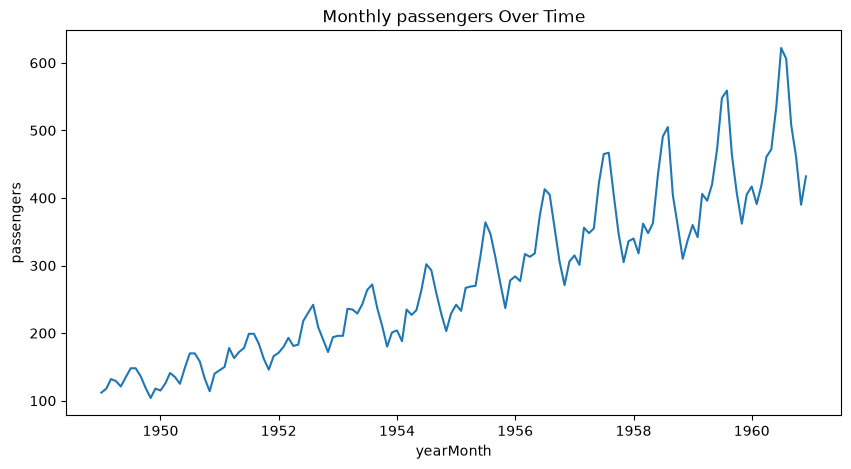

In [6]:
#visualize the data
 
plt.figure(figsize = (10,5))
sns.lineplot(x = airP.index, y= airP['passengers'])
plt.title("Monthly passengers Over Time")
plt.show()


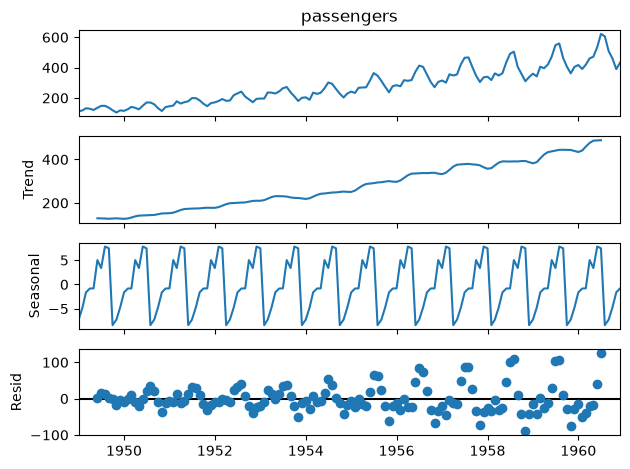

In [15]:
# decompose to check trend and seasonality 

decomposition = seasonal_decompose(airP.passengers, period=10)
decomposition.plot()
plt.show()

In [18]:
# stationary check
def test_stationarity(dataFrame, var, window = 12):
    dataFrame['rollMean'] = dataFrame[var].rolling(window=window).mean()
    dataFrame['rollStd'] = dataFrame[var].rolling(window=window).std()

    adf_result = adfuller(dataFrame[var])

    p_value = adf_result[1]

    print(f'ADF p-value: {p_value:.4f}')
    if p_value < 0.05:
        print('The time series is stationary (reject h0)')
    else:
        print('The time series is not stationary (fail to reject h0)')

    plt.Figure(figsize=(10,5))
    sns.lineplot(x = dataFrame.index, y = dataFrame[var], label = 'Original')
    sns.lineplot(x = dataFrame.index, y = dataFrame['rollMean'], label = 'Rolling Mean')
    sns.lineplot(x = dataFrame.index, y = dataFrame['rollStd'], label = 'Rolling Std')

    plt.title('Rolling Statistics')
    plt.legend() 
    plt.show()
    

ADF p-value: 0.9919
The time series is not stationary (fail to reject h0)


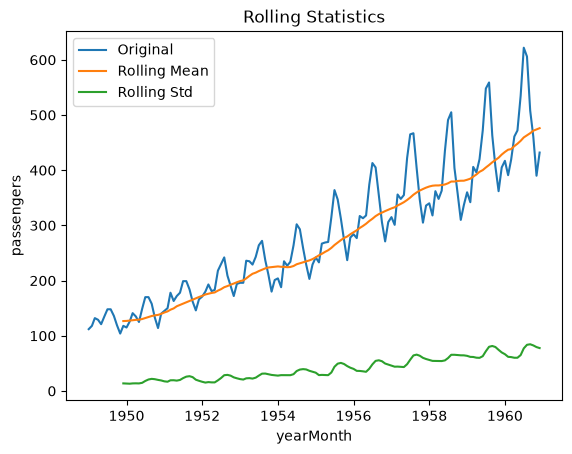

In [21]:
# test stationarity
test_stationarity(airP, 'passengers')

            passengers    rollMean    rollStd  shift  shiftDiff
yearMonth                                                      
1949-01-01         112         NaN        NaN    NaN        NaN
1949-02-01         118         NaN        NaN  112.0        6.0
1949-03-01         132         NaN        NaN  118.0       14.0
1949-04-01         129         NaN        NaN  132.0       -3.0
1949-05-01         121         NaN        NaN  129.0       -8.0
1949-06-01         135         NaN        NaN  121.0       14.0
1949-07-01         148         NaN        NaN  135.0       13.0
1949-08-01         148         NaN        NaN  148.0        0.0
1949-09-01         136         NaN        NaN  148.0      -12.0
1949-10-01         119         NaN        NaN  136.0      -17.0
1949-11-01         104         NaN        NaN  119.0      -15.0
1949-12-01         118  126.666667  13.720147  104.0       14.0
1950-01-01         115  126.916667  13.453342  118.0       -3.0
1950-02-01         126  127.583333  13.1

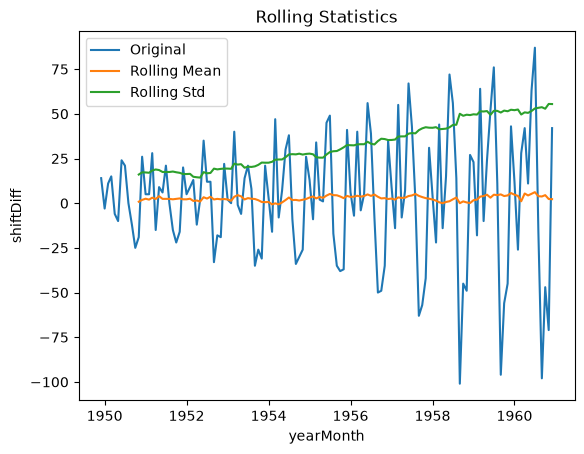

In [26]:
# not stationary   ... try with diff of 1 
airP['shift'] = airP.passengers.shift(1)
airP['shiftDiff'] = airP['passengers'] - airP['shift']
print(airP.head(20))

test_stationarity(airP.dropna(), 'shiftDiff')


            passengers    rollMean    rollStd  shift  shiftDiff
yearMonth                                                      
1949-01-01         112         NaN        NaN    NaN        NaN
1949-02-01         118         NaN        NaN    NaN        NaN
1949-03-01         132         NaN        NaN  112.0       20.0
1949-04-01         129         NaN        NaN  118.0       11.0
1949-05-01         121         NaN        NaN  132.0      -11.0
1949-06-01         135         NaN        NaN  129.0        6.0
1949-07-01         148         NaN        NaN  121.0       27.0
1949-08-01         148         NaN        NaN  135.0       13.0
1949-09-01         136         NaN        NaN  148.0      -12.0
1949-10-01         119         NaN        NaN  148.0      -29.0
1949-11-01         104         NaN        NaN  136.0      -32.0
1949-12-01         118  126.666667  13.720147  119.0       -1.0
1950-01-01         115  126.916667  13.453342  104.0       11.0
1950-02-01         126  127.583333  13.1

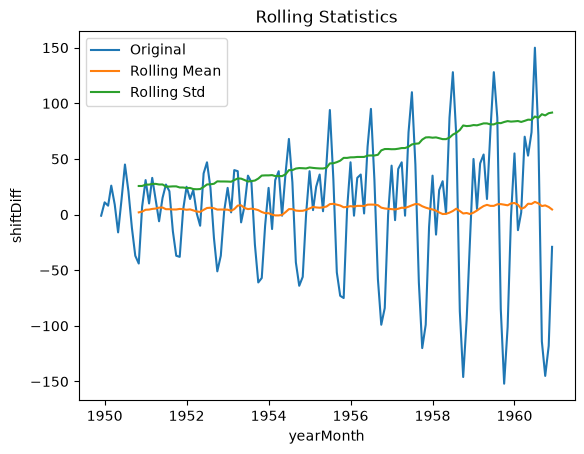

In [24]:
# not stationary   ... try with diff of 2
airP['shift'] = airP.passengers.shift(2)
airP['shiftDiff'] = airP['passengers'] - airP['shift']
print(airP.head(20))

test_stationarity(airP.dropna(), 'shiftDiff')
# stationary

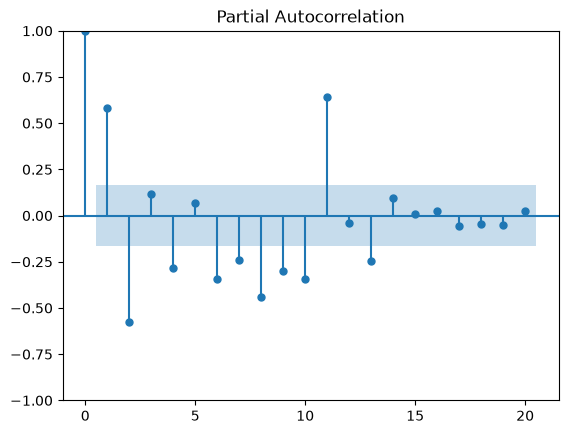

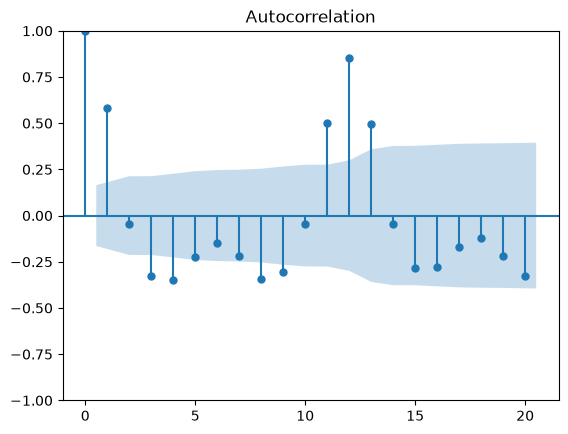

In [ ]:
#  for ACF - Differencing of 2 and 12 
airP['SecondDiff'] = airP['passengers'].diff(2)
airP['Diff12'] = airP['passengers'].diff(12)

# PACF and ACF plots 
plot_pacf(airP['SecondDiff'].dropna(), lags=20) # gives p (i.e AR value )  value for the aima function
plt.show()

plot_acf(airP['SecondDiff'].dropna(), lags = 20) # gives q i.e MA  value for the ARIMA function 
plt.show()


# train test split
train_size = int(len(airP)*0.7)
train= airP.iloc[:train_size]
test = airP.iloc[train_size:]


# any value in blue zone should not consider 


In [30]:
# ARIMA model 
model_arima = ARIMA(train['passengers'], order=(1,2,1))
model_arima_fit = model_arima.fit()
arima_pred = model_arima_fit.predict(start = len(train), end = len(airP)-1)

# add arima prediction to dataframe 
airP['arimaPred'] = np.nan
airP.iloc[train_size:, airP.columns.get_loc('arimaPred')] = arima_pred.values 
print(airP.tail())

            passengers    rollMean    rollStd  ...  SecondDiff  Diff12   arimaPred
yearMonth                                      ...                                
1960-08-01         606  463.333333  83.630500  ...        71.0    47.0  439.708765
1960-09-01         508  467.083333  84.617276  ...      -114.0    45.0  442.074511
1960-10-01         461  471.583333  82.541954  ...      -145.0    54.0  444.440256
1960-11-01         390  473.916667  79.502382  ...      -118.0    28.0  446.806002
1960-12-01         432  476.166667  77.737125  ...       -29.0    27.0  449.171747

[5 rows x 8 columns]


e:\Installed_Applications\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


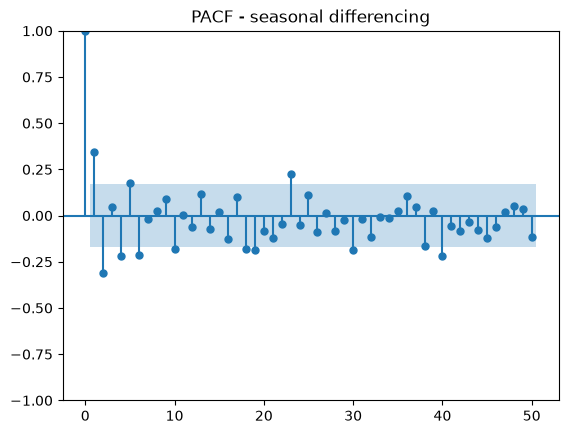

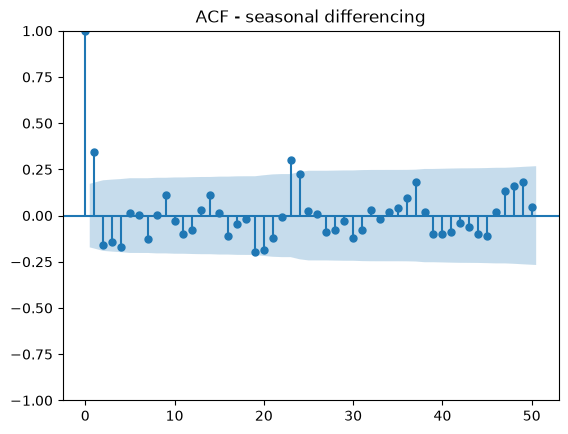

e:\Installed_Applications\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            passengers    rollMean  ...  diff_combined  sarimaxPred
yearMonth                           ...                            
1959-05-01         420  397.083333  ...           13.0   439.142392
1959-06-01         472  400.166667  ...          -11.0   509.186658
1959-07-01         548  404.916667  ...            0.0   563.022434
1959-08-01         559  409.416667  ...           17.0   546.809933
1959-09-01         463  414.333333  ...            2.0   482.360891
1959-10-01         407  418.333333  ...           -6.0   421.397597
1959-11-01         362  422.666667  ...           -7.0   375.166926
1959-12-01         405  428.333333  ...           20.0   420.682953
1960-01-01         417  433.083333  ...            5.0   431.814790
1960-02-01         391  437.166667  ...          -19.0   410.038453
1960-03-01         419  438.250000  ...          -44.0   476.417178
1960-04-01         461  443.666667  ...           16.0   466.872808
1960-05-01         472  448.000000  ...         

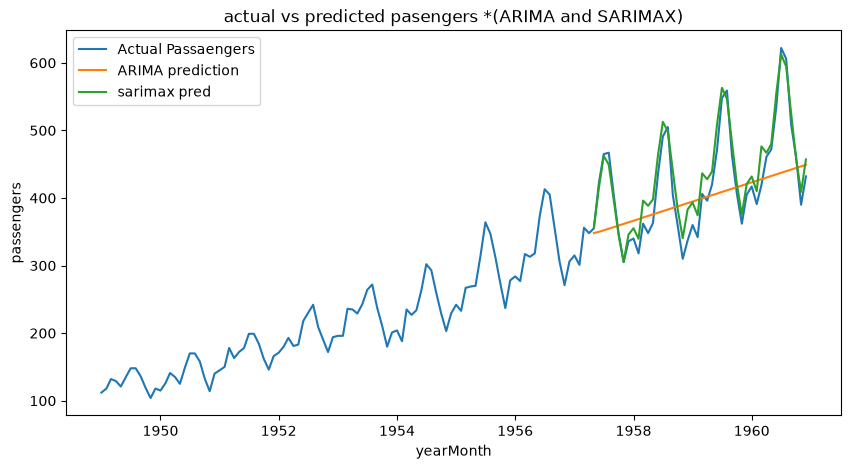

In [ ]:
# to calculate p and q for sarimax

airP['diff_combined'] = airP['passengers'].diff(2).diff(12)

plot_pacf(airP['diff_combined'].dropna(), lags= 50)
plt.title("PACF - seasonal differencing")
plt.show()


plot_acf(airP['diff_combined'].dropna(), lags= 50)
plt.title("ACF - seasonal differencing")
plt.show()

model_sarimax = SARIMAX(train['passengers'], order=(1,2,1), seasonal_order=(1,2,1,12))
model_sarimax_fit = model_sarimax.fit()
sarimax_pred = model_sarimax_fit.predict(start = len(train), end = len(airP) -1)

# add SARIMAX prediction to df 
airP['sarimaxPred'] = np.nan
airP.iloc[train_size:, airP.columns.get_loc('sarimaxPred')] = sarimax_pred.values
print(airP.tail(20))


# plot predictions 
plt.figure(figsize = (10,5))
sns.lineplot(x = airP.index, y=airP['passengers'], label='Actual Passaengers')
sns.lineplot(x = airP.index, y=airP['arimaPred'], label='ARIMA prediction')
sns.lineplot(x = airP.index, y=airP['sarimaxPred'], label='sarimax pred')
plt.title('actual vs predicted pasengers (ARIMA and SARIMAX)')
plt.legend()
plt.show()

In [34]:
# future forecast using sarimax 
future_dates = pd.DataFrame(pd.date_range(start='1961-01-01', end='1962-12-01', freq='MS'), columns=['Dates']) 
future_dates.set_index('Dates', inplace=True)

future_forecast = model_arima_fit.predict(start=future_dates.index[0], end=future_dates.index[-1])
print(future_forecast)

1961-01-01    451.537493
1961-02-01    453.903238
1961-03-01    456.268984
1961-04-01    458.634730
1961-05-01    461.000475
1961-06-01    463.366221
1961-07-01    465.731966
1961-08-01    468.097712
1961-09-01    470.463457
1961-10-01    472.829203
1961-11-01    475.194948
1961-12-01    477.560694
1962-01-01    479.926440
1962-02-01    482.292185
1962-03-01    484.657931
1962-04-01    487.023676
1962-05-01    489.389422
1962-06-01    491.755167
1962-07-01    494.120913
1962-08-01    496.486659
1962-09-01    498.852404
1962-10-01    501.218150
1962-11-01    503.583895
1962-12-01    505.949641
Freq: MS, Name: predicted_mean, dtype: float64


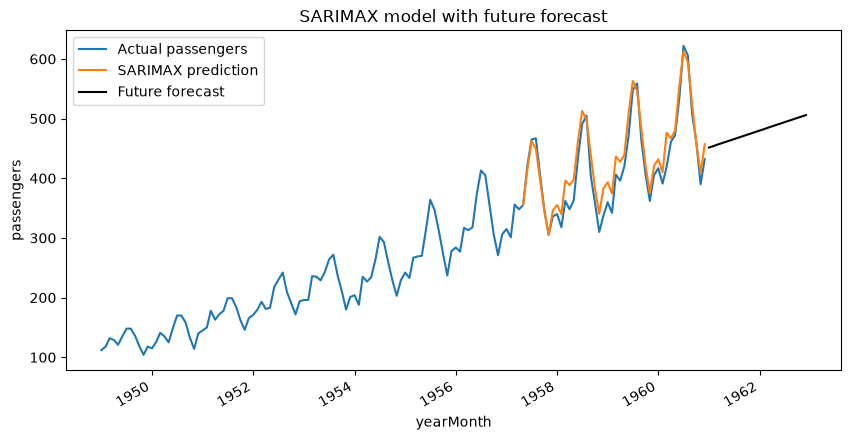

In [35]:
# plot future forecast 
plt.figure(figsize=(10,5))
sns.lineplot(x= airP.index, y = airP['passengers'], label = 'Actual passengers')
sns.lineplot(x= airP.index, y = airP['sarimaxPred'], label = 'SARIMAX prediction')

future_forecast.plot(color='black', label = 'Future forecast')
plt.title('SARIMAX model with future forecast')
plt.legend()
plt.show()

In [36]:
# model evaluation
actual = test['passengers']

In [ ]:
# ARIMA Metrics 
arimax_mae = mean_absolute_error(actual, arima_pred)
arimax_mse = mean_squared_error(actual, arima_pred)
arimax_mse = math.sqrt(arimax_mse)
arimax_rmse = math.sqrt(arimax_mse)
arimax_r2 = r2_score(actual, arimax_pred)
print(f'SARIMAX -> MAE: {sarimax_mae:.2f}, RMSE: {sarimax_rmse:.2f}, r2: {sarimax_r2:.2f} ')

SARIMAX -> MAE: 53.92, RMSE: 8.43, r2: 0.90 


In [ ]:
# SARIMAX Metrics 
sarimax_mae = mean_absolute_error(actual, sarima_pred)
sarimax_mse = mean_squared_error(actual, arima_pred)
sarimax_mse = math.sqrt(arimax_mse)
sarimax_rmse = math.sqrt(arimax_mse)
sarimax_r2 = r2_score(actual, arimax_pred)
print(f'SARIMAX -> MAE: {sarimax_mae:.2f}, RMSE: {sarimax_rmse:.2f}, r2: {sarimax_r2:.2f} ')